In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

### Load dataset

In [2]:
# Load csv dataset
df = pd.read_csv("datasets/jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
# No of rows and columns
df.shape

(420451, 15)

In [4]:
# Column names
df.columns

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='str')

### Analyzing Data

In [5]:
# Start and End dates
df["Date Time"].min(), df["Date Time"].max()

('01.01.2009 00:10:00', '31.12.2016 23:50:00')

In [6]:
# Temperature only
temperature = df["T (degC)"]

# All but date
raw_data = df[['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)']]
temperature.shape, raw_data.shape

((420451,), (420451, 14))

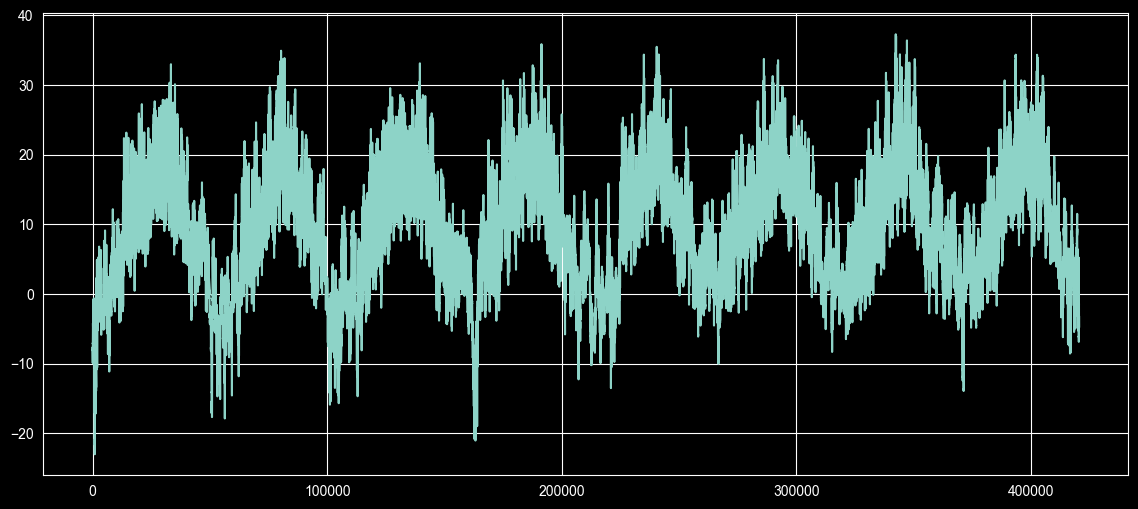

In [7]:
# All of temperature plotted
plt.figure(figsize=(14, 6))
plt.plot(range(len(temperature)), temperature)

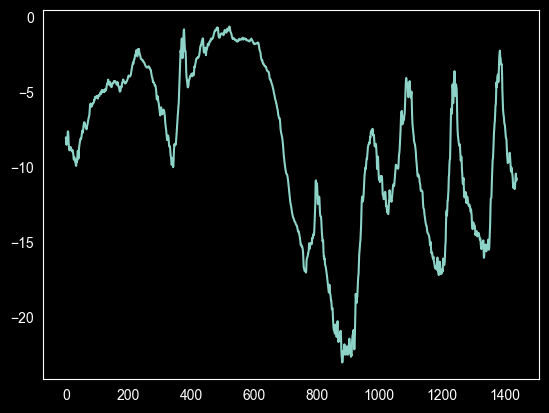

In [8]:
# Temperature on first 10 days
days = 10
plt.grid(False)
number_of_data_points = days * 24 * 6 # one data point = 10 min
plt.plot(range(number_of_data_points), temperature[:number_of_data_points])

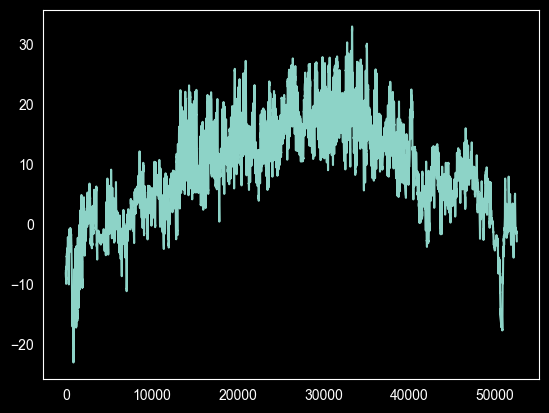

In [9]:
# Temperature on first 1 year
days = 365
plt.grid(False)
number_of_data_points = days * 24 * 6 # one data point = 10 min
plt.plot(range(number_of_data_points), temperature[:number_of_data_points])

### Data Prep

In [10]:
# Train - Test - Val Split count
num_train_samples = int(0.5 * len(raw_data)) # 50%
num_val_samples = int(0.25 * len(raw_data)) # 25%
num_test_samples = len(raw_data) - num_train_samples - num_val_samples # 25%

print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [11]:
# Normalize
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [12]:
# Train - Test - Val Split Config
sampling_rate = 6  # Observations will be sampled at one data point per hour: we will only keep one data point out of six.
sequence_length = 120  # Observations will go back five days (120 hours)
delay = sampling_rate * (sequence_length + 24 - 1) #  The target for a sequence will be the temperature 24 hours after the end of the sequence.
batch_size = 256


In [13]:
# Train - Test - Val Split
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [14]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


In [15]:
targets

<tf.Tensor: shape=(256,), dtype=float64, numpy=
array([ 6.080e+00,  2.840e+00,  1.572e+01,  1.492e+01,  1.700e+01,
        1.448e+01, -4.430e+00,  3.030e+00,  3.000e+00,  1.153e+01,
        7.600e+00,  6.330e+00, -2.970e+00,  1.899e+01,  2.042e+01,
        8.140e+00,  9.530e+00,  1.800e+01, -1.434e+01,  1.667e+01,
        1.570e+01,  1.379e+01,  1.364e+01,  1.704e+01,  6.590e+00,
        1.641e+01,  3.460e+00,  9.910e+00,  1.079e+01,  1.580e+01,
        1.200e+00, -6.940e+00, -2.190e+00,  1.410e+01,  9.150e+00,
        6.230e+00,  8.700e+00,  6.550e+00,  1.214e+01,  1.620e+00,
        1.467e+01,  1.634e+01,  2.440e+00, -9.900e+00,  5.210e+00,
       -6.020e+00,  1.058e+01,  2.479e+01,  1.273e+01,  3.590e+00,
        3.580e+00,  1.313e+01,  4.000e+00,  1.401e+01,  1.376e+01,
        1.673e+01,  1.938e+01, -1.203e+01,  5.140e+00,  2.459e+01,
       -4.170e+00,  6.070e+00, -5.250e+00,  1.970e+00,  1.684e+01,
        3.085e+01,  3.540e+01,  1.503e+01,  1.824e+01,  1.100e+00,
        5.250e

### Baseline Evaluation

In [16]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std["T (degC)"] + mean["T (degC)"]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

evaluate_naive_method(val_dataset)
print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


### Simple Dense Model

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = keras.layers.Flatten()(inputs)
x = keras.layers.Dense(16, activation="relu")(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks=callbacks)
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 15.8672 - mae: 2.9968 - val_loss: 10.9403 - val_mae: 2.5990
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 9.2361 - mae: 2.3980 - val_loss: 10.2005 - val_mae: 2.5234
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 8.5649 - mae: 2.3054 - val_loss: 10.3000 - val_mae: 2.5339
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 8.2067 - mae: 2.2527 - val_loss: 10.2807 - val_mae: 2.5386
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 7.9310 - mae: 2.2119 - val_loss: 10.4625 - val_mae: 2.5652
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 7.6373 - mae: 2.1712 - val_loss: 10.5050 - val_mae: 2.5711
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 7.4777 - mae: 2.1467 - val_loss: 11.3067 - val_mae: 2.6698
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 7.3151 - mae: 2.1234 - val_loss: 10.7558 - val_mae: 2.6025
Epoch 9/10
819/819 ━━━━━━━━━━━━

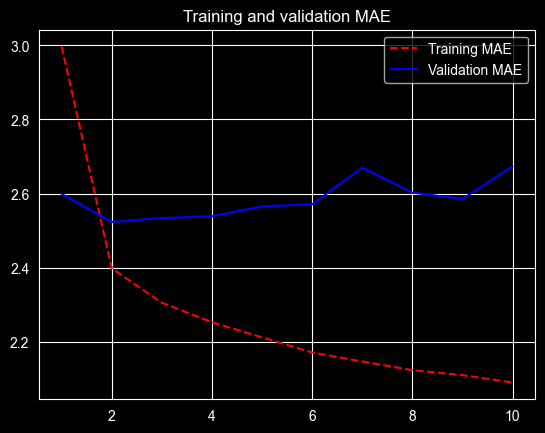

In [18]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### 1D Conv Model

In [19]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = keras.layers.Conv1D(8, 24, activation="relu")(inputs)
x = keras.layers.MaxPooling1D(2)(x)
x = keras.layers.Conv1D(8, 12, activation="relu")(x)
x = keras.layers.MaxPooling1D(2)(x)
x = keras.layers.Conv1D(8, 6, activation="relu")(x)
x = keras.layers.GlobalAveragePooling1D()(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks=callbacks)
model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 24.3183 - mae: 3.7479 - val_loss: 15.0095 - val_mae: 3.0577
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 14.1904 - mae: 2.9817 - val_loss: 14.5315 - val_mae: 3.0045
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 12.5248 - mae: 2.8023 - val_loss: 16.3537 - val_mae: 3.2316
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 11.5741 - mae: 2.6947 - val_loss: 14.0669 - val_mae: 2.9462
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 10.9762 - mae: 2.6231 - val_loss: 14.0463 - val_mae: 2.9406
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 10.5430 - mae: 2.5719 - val_loss: 14.0900 - val_mae: 2.9548
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 10.1516 - mae: 2.5232 - val_loss: 14.2456 - val_mae: 2.9699
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 9.8900 - mae: 2.4931 - val_loss: 14.4926 - val_mae: 3.0098
Epoch 9/10
819/819 ━━━━━━

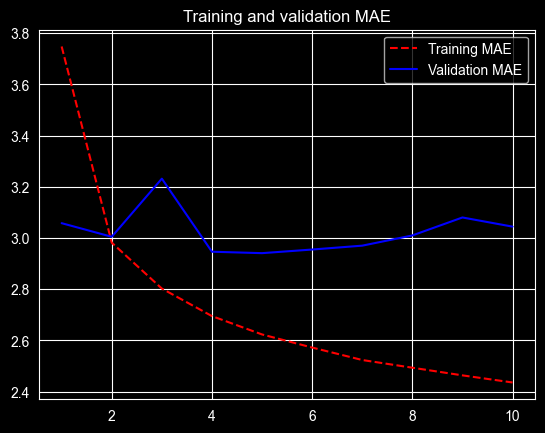

In [20]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### RNN - LSTM

In [21]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = keras.layers.LSTM(16)(inputs)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
callbacks = [keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 65ms/step - loss: 45.7396 - mae: 4.9534 - val_loss: 17.6723 - val_mae: 3.1249
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 14.2307 - mae: 2.8610 - val_loss: 11.2909 - val_mae: 2.5544
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 10.8541 - mae: 2.5547 - val_loss: 10.1991 - val_mae: 2.4527
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - loss: 9.7953 - mae: 2.4391 - val_loss: 9.8398 - val_mae: 2.4233
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 9.3440 - mae: 2.3844 - val_loss: 9.7208 - val_mae: 2.4131
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - loss: 8.9132 - mae: 2.3317 - val_loss: 9.6657 - val_mae: 2.4061
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 8.7342 - mae: 2.3076 - val_loss: 9.6040 - val_mae: 2.3983
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 9.0586 - mae: 2.3287 - val_loss: 9.3453 - val_mae: 2.3821
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

In [24]:
model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 10.7356 - mae: 2.5654
Test MAE: 2.57


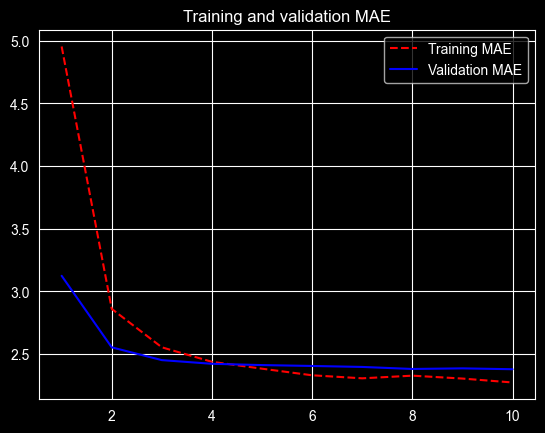

In [27]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()